# Pipeline d'imagerie planétaire en astrophotographie
*Par: Nicolas Payot, Gabriel Missael Barco, Auriane Thilloy, Olivia Pereira*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/GabrielMissael/super-resolution-workshop/blob/master/notebooks/Traditional_pipeline_Planetary_Imaging.ipynb
)      [![View on GitHub](https://img.shields.io/badge/View_on-GitHub-black?logo=github)](
https://github.com/GabrielMissael/super-resolution-workshop
)

Dans ce notebook, nous allons suivre un **vrai pipeline d’astrophotographie**, depuis les données brutes du télescope jusqu’à une **belle image finale** :

- calibration de la caméra,
- sélection et empilement des meilleures images,
- amélioration des détails,
- et réglages de couleur et de contraste.

L’idée est de survoler les étapes pour obtenir une image de planète à partir des données obtenues du télescope.

<br>
<div>
<img src="https://images.nicolaspayot.ca/super-rez-workshop/pipeline_result_planet.png" width="800"/>
</div>
<br>

## 0. Comment utiliser ce notebook

Dans ce notebook, tu verras parfois des **options** à sélectionner. Ces éléments sont expliqués dans les cellules au-dessus. Si tu as des questions, n'hésite pas à nous les poser.

Pour exécuter une cellule :

1. Clique sur le bouton ▶️ à gauche de la cellule. (Ou entre shift+enter sur ton clavier après avoir sélectionné la cellule.)
2. Attends que l’image ou le résultat apparaisse.

> **Important** : choisis les options désirées **avant** de lancer la cellule.
> Si tu changes un paramètre, relance simplement la cellule pour mettre à jour le résultat.

Tu n’es pas obligé.e de regarder le code, mais tu peux toujours le dévoiler si tu veux voir la machinerie cachée.

## 1. Contexte : imagerie planétaire vs ciel profond

Toutes les images d’astronomie ne se traitent pas de la même manière.
On distingue principalement deux cas :

### Imagerie planétaire (Lune, planètes, parfois Soleil)

- On filme à **très courte exposition** avec une **haute cadence** (vidéo, rafales).
- La **turbulence atmosphérique** change vite : certaines images sont nettes, d’autres très floues.
- On utilise souvent le **lucky imaging** :
  - on garde seulement les **meilleures trames**,
  - on les aligne,
  - puis on les empile pour gagner en détails.

On travaille souvent sur une **petite région** (ROI) autour de la planète, avec un recentrage très précis puisque la planète est très petite.

<br>
<div>
<img src="https://images.nicolaspayot.ca/super-rez-workshop/sensor_roi.png" width="800"/>
</div>

**Figure** : Exemple de la taille de la planète sur le senseur.

<br>

---

### Imagerie du ciel profond (nébuleuses, galaxies, amas…)

- On fait des **poses plus longues** pour augmenter le **rapport signal/bruit (SNR)**.
- La **calibration** est cruciale :
  on utilise des **bias**, **darks** et **flats** pour corriger l’instrument.
- L’**empilement** sert surtout à :
  - lisser le bruit,
  - supprimer les **pixels chauds**,
  - éliminer les traces de **rayons cosmiques**,
  - et révéler les structures faibles.

Dans ce notebook, nous verrons des idées qui s’appliquent au **premier contexte**. Un second notebook est dédié à l'imagerie du ciel profond (DSO).

## 2. Vue d’ensemble du pipeline

Voici les grandes étapes d’un traitement typique en astrophotographie :

1. Acquisition & métadonnées
2. Calibration instrumentale
3. Dématriçage / débayerisation
4. Alignement des images
5. Sélection des meilleures trames
6. Empilement (stacking)
7. Restauration & détails fins
8. Réduction du bruit
9. Couleur & contraste

Les cellules suivantes détailleront quelques étapes, avec des exemples visuels et des paramètres à explorer.

Dans ce notebook, vous pouvez choisir entre des images de **Jupiter** ou de **Mars** provenant du télescope que vous pourrez utiliser plus tard.


In [ ]:
# @title Téléchargement des scripts nécessaires
# !rm -r super-resolution-workshop/
!git clone --quiet https://github.com/GabrielMissael/super-resolution-workshop

In [ ]:
# @title Téléchargement des données

planete = "mars" # @param ["jupiter","mars"]

import sys
sys.path.append("super-resolution-workshop")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
from ipywidgets import interact, FloatSlider, IntSlider

from src.process.enhance import unsharp_mask_color, denoise_color, adjust_saturation, adjust_contrast_brightness, laplacian_pyramid_sharpen
from src.demosaic.debayer import debayer_stack
from src.io.trim_jupiter_images import get_frames
from src.process.quality_and_align import compute_quality_scores, choose_reference_frame, detect_ref_points, align_frames
from src.visual.visualize_results import overlay_points
from src.process.stacking import stack_by_quality

if planete == "jupiter":
    data = get_frames("super-resolution-workshop/data/jupiter_frames.avi")
else:
    data = get_frames("super-resolution-workshop/data/mars_frames.avi")[:10000]
print(f"Data loaded successfully! Data contains {len(data)} images.")

In [ ]:
# @title
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(data[0], cmap="gray")
ax.axis("off")
plt.tight_layout()


def animate(i):
    im.set_data(data[i])
    return [im]


ani = animation.FuncAnimation(fig, animate, frames=120,
                              interval=1000.0 / 30, blit=True)
html_video = HTML(ani.to_html5_video())
plt.close(fig)
html_video

## 4. Motifs Bayer (CFA) en astrophotographie

Dans cette section, nous découvrirons ce qu’est un **motif Bayer**, pourquoi il existe, et comment il influence les images astronomiques.
ous verrez aussi comment cela affecte le traitement des images planétaires et du ciel profond. La compréhension de ce qu'est un motif bayer n'est pas essentielle au notebook, donc vous pouvez sauter cette section d'information si vous ne la comprenez pas.

## 5. Qu’est-ce qu’un motif Bayer ?

Les capteurs d’appareil photo (CMOS/CCD) ne voient pas la couleur :
ils ne mesurent qu’une **intensité lumineuse**.

Pour obtenir une image couleur, on place au-dessus du capteur une grille de **minuscules filtres** — un **motif Bayer**, aussi appelé *Color Filter Array (CFA)*.

Dans la version la plus courante, chaque carré 2×2 contient :

- **2 pixels verts**
- **1 pixel rouge**
- **1 pixel bleu**

Cette mosaïque peut être arrangée selon plusieurs schémas :
`RGGB`, `BGGR`, `GRBG`, `GBRG` (voir figure ci-dessous).

Le capteur enregistre donc une **image monochrome avec un motif coloré**.
C’est pour cela que les images RAW (par exemple d’une planète) ont un aspect **grillagé** ou pixelisé avant traitement.
C'est le même principe que ce soit pour un appareil photo dans un télescope ou dans un téléphone.

![image](https://www.researchgate.net/publication/346065538/figure/fig1/AS:11431281415313211@1746032796306/Bayer-patterns-a-BGGR-b-GBRG-c-GRBG-and-d-RGGB.tif)

**Figure :** Exemples de motifs Bayer courants.

## 6. Pourquoi utilise-t-on un motif Bayer ?

Quelques raisons très simples :

1. **Les photodiodes ne distinguent pas les couleurs**
    - Un pixel détecte juste “la quantité de lumière”.
    - Le filtre Bayer permet d’échantillonner le **rouge, vert et bleu** séparément.

2. **Plus de vert pour une meilleure netteté**
    - Le motif contient *deux* pixels verts par bloc 2×2 car :
        - l’œil humain est plus sensible au vert,
        - la **luminance** (la composante qui donne la netteté) dépend surtout du vert,

    - Résultat :
        une meilleure résolution apparente, et moins de bruit dans la structure de l’image.

![image](https://cdn.shopify.com/s/files/1/1594/4815/files/astrophotography_101_the_bayer_filter_system_1.png?v=1605645318)

**Figure :** Effets des filtres sur la lumière dans un motif Bayer.

## 7. Comment traiter un motif Bayer en astrophotographie ?

Le dématriçage (ou **débayerisation**) consiste à reconstruire une image couleur à partir de la mosaïque RGGB / BGGR / GRBG / GBRG du capteur.
Chaque pixel du capteur ne voit qu’une seule couleur : le dématriçage sert donc à **interpoler les deux autres couleurs** pour créer une image RGB complète.

Dans ce notebook, vous pouvez choisir parmi plusieurs méthodes :

- **Bilinéraire** : rapide et simple, idéal pour prévisualiser ou pour une première étape de traitement.
- **VNG** (Variable Number of Gradients) : meilleur respect des contours, réduit les artefacts en zones détaillées.
- **EH** (Edge-Aware) : rapide et élimine les artéfacts colorés sur les arêtes.


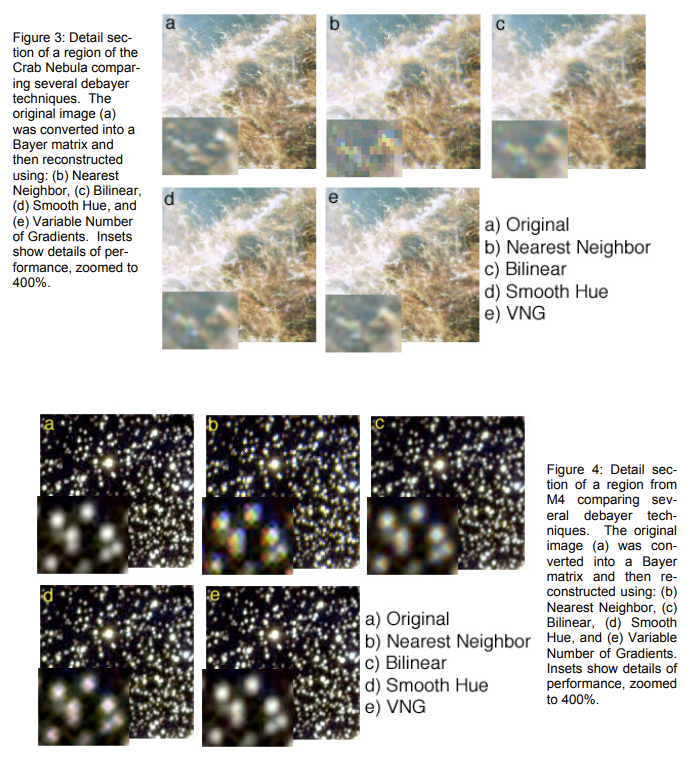

**Figure**: Exemples de méthodes de dématriçage.

---

### Dans la cellule suivante…

Vous pourrez sélectionner :

- le motif Bayer correspondant à votre caméra (RGGB, BGGR, GRBG, GBRG),
- l’algorithme de dématriçage,
- et visualiser le résultat directement.

L’objectif est simplement de **voir comment votre image RAW couleur est reconstruite**, et de voir l’impact des différents choix sur le rendu final.

In [ ]:
pattern = "RGGB" #@param ['RGGB', 'GRBG', 'GBRG', 'BGGR'] {'type':'string'}
method = "Bilinear" #@param ['VNG', 'Bilinear', 'EA'] {'type':'string'}


deb_frames = debayer_stack(data, pattern=pattern, method=method)
plt.imshow(deb_frames[0])
plt.axis("off")
plt.show()

## 8. Lucky imaging

Nous avons vu sous quel format nos images sortent du telescope, mais nous n'avons pas encore traité du nombre d'images requises pour obtenir une image d'une planète. Vous avez peut-être remarqué que nous avons des milliers d'images de Jupiter ou de Mars. Voici pourquoi :

Le *lucky imaging* est une technique très utilisée en imagerie planétaire pour obtenir des images beaucoup plus nettes malgré la turbulence atmosphérique.

L’idée est simple :
on prend **des milliers d’images très courtes** (quelques millisecondes).

Chaque image “gèle” la turbulence à un instant donné. Parmi cette longue série, certaines images seront exceptionnellement nettes : ce sont les **images chanceuses**.

Grâce à cette technique, on peut approcher la **résolution limite du télescope**, comme si l’on observait depuis l’espace.

## 9. Pourquoi la turbulence pose problème ?

L’atmosphère est faite de couches d’air qui bougent sans arrêt, avec des températures et densités variables.

Ces variations modifient **l’indice de réfraction**, déviant en permanence la lumière des astres.
L’image d’une planète se déforme ainsi **des centaines de fois par seconde**.

Lors d’une longue pose, toutes ces petites distorsions s’additionnent → les détails s’étalent → l’image devient floue.

Ce phénomène est appelé **le seeing**.

![seeing](https://cdn.shopify.com/s/files/1/1594/4815/files/ao_mov_1hz.gif?12010976029697425586)

**Figure :** Simulation du seeing sur une étoile.

## 10. Comment sélectionne-t-on les meilleures images ?

Voici les principales étapes du *lucky imaging* :

1. **Mesure de la qualité** :
   Pour chaque image, on calcule un indicateur de netteté
   (contraste, gradients, FWHM, énergie haute fréquence…).

2. **Classement et sélection** :
   On trie toutes les images et on garde seulement les **meilleures**
   (souvent entre **1 % et 20 %**).

3. **Alignement** :
   Les images retenues sont recadrées et recalées pour corriger
   les petites dérives du télescope et les mouvements atmosphériques.

4. **Empilement (stacking)** :
   Les images alignées sont combinées pour augmenter le **SNR**
   et faire ressortir les détails fins.


Dans les prochaines cellules, on calcule la qualité des images et on les trie en fonction de cet indice. Remarquez la différence entre nos meilleures images et les pires.

In [ ]:
# @title
# scores, _, _ = compute_quality_scores(deb_frames)
if planete == "jupiter":
  scores = np.load("super-resolution-workshop/data/scores.npz")["arr_0"]
else:
  scores = np.load("super-resolution-workshop/data/mars_scores.npz")["arr_0"]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(scores, '-k')
ax.set_xlabel('frame')
ax.set_ylabel('quality (normalized)')
ax.set_title('Per-frame quality scores')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.sort(scores)[::-1], '-k')
ax.set_xlabel('frame')
ax.set_ylabel('quality (normalized)')
ax.set_title('Sorted per-frame quality scores')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [ ]:
num_images = 5 # @param {'type':'integer'}
N = num_images

sorted_indices = np.argsort(scores)
worst_indices = sorted_indices[:N]
best_indices = sorted_indices[-N:][::-1]

fig, axs = plt.subplots(2, N, figsize=(3 * N, 6.75))

for i in range(N):
    idx = best_indices[i]
    axs[0, i].imshow(deb_frames[idx])
    axs[0, i].set_title(f"Best {i + 1}\nIdx: {idx}\nScore: {scores[idx]:.3f}")
    axs[0, i].axis('off')

    idx = worst_indices[i]
    axs[1, i].imshow(deb_frames[idx])
    axs[1, i].set_title(f"Worst {i + 1}\nIdx: {idx}\nScore: {scores[idx]:.3f}")
    axs[1, i].axis('off')

plt.suptitle("Top: Best Frames (High Score)\nBottom: Worst Frames (Low Score)")
plt.tight_layout()
plt.show()

## 11. Alignement et empilement (_stacking_)

### Alignement

Dans la cellule suivante, vous verrez les **points de référence** détectés automatiquement sur l’image.
Ces points servent à retrouver les mêmes structures dans toutes les images à aligner. Le positionnement des points est automatique et priorise des détails reconaissables.

> Après un certain nombre de points, il n'est plus possible d’en ajouter davantage : ils doivent être suffisamment espacés les uns des autres.

<br>
<div>
<img src="https://images.nicolaspayot.ca/super-rez-workshop/pipeline_align_stack_planet.png" width="1200"/>
</div>
<br>

### Empilement (_stacking_)

Vous devez maintenant choisir **combien d’images** seront combinées (`num_to_stack = ...`).
Plus vous empilez d’images → **moins de bruit** → meilleur contraste.
Mais empiler des images trop floues réduit les détails fins : il faut trouver un équilibre.

Choisissez ensuite la méthode d’empilement avec `stacking_method = ...`.

Méthodes disponibles :

- **average** — moyenne simple, bon SNR.
- **median** — robuste aux outliers.
- **sigma** — *sigma clipping*, supprime les valeurs aberrantes.
- **trimmed** — ne conserve que les images les plus cohérentes entre elles.
- **weighted** — moyenne pondérée selon le score de qualité.
- **winsorized** — remplace les valeurs aberrantes par des valeurs plausibles.

Vous pouvez comparer plusieurs méthodes en même temps :
`stacking_method = "average, median, sigma"`

In [ ]:
# @title
reference_idx = choose_reference_frame(scores)
reference_frame = deb_frames[reference_idx]

num_points_reference = 30 # @param {'type': 'integer'}
ref_pts = detect_ref_points(reference_frame, max_corners=num_points_reference)

image = overlay_points(reference_frame, ref_pts, (1, 0, 0), alpha=0.3)
plt.imshow(image)
plt.show()

In [ ]:
stacking_methods = ["weighted", "average", "median", "sigma", "trimmed", "winsorized"]
stacking_method = "average" # @param ["weighted","average","median","sigma", "trimmed","winsorized","ALL"] {"allow-input":true}
num_to_stack = 100 #@param {'type': 'integer'}

if stacking_method == "ALL":
    stacking_methods = stacking_methods
else:
    if "," in stacking_method:
        stacking_methods = [method.strip() for method in stacking_method.split(",")]
    else:
        stacking_methods = [stacking_method]

print(f"Stacking methods: {stacking_methods}")

idx_to_align = sorted_indices[-num_to_stack:][::-1]
reference_idx = 0

aligned, transforms = align_frames(deb_frames[idx_to_align], reference_idx, ref_pts)

stacks = []
for method in stacking_methods:
    stack = stack_by_quality(aligned, scores=scores[idx_to_align], method=method)
    stacks.append(stack)
stacked = np.stack(stacks).astype(np.uint8)

n = stacked.shape[0]

fig, axs = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axs = [axs]
for i in range(n):
    axs[i].imshow(stacked[i])
    axs[i].set_title(f"{stacking_methods[i].capitalize()}")
    axs[i].axis('off')
plt.tight_layout()
plt.show()

## 12. Traitement d’image

Une fois vos images alignées et empilées, vous pouvez appliquer quelques réglages simples pour améliorer le rendu visuel.
Ces opérations sont similaires à ce que l’on ferait dans Photoshop ou GIMP, mais adaptées ici à l’imagerie planétaire.

<br>
<div>
<img src="https://images.nicolaspayot.ca/super-rez-workshop/pipeline_sharpening.png" width="800"/>
</div>
<br>

Dans les cellules suivantes, vous pourrez tester trois familles d’outils :

- **amélioration de la netteté**,
- **réduction du bruit**,
- **ajustement des couleurs**.

Chaque outil peut être activé ou réglé via des paramètres simples.

## 13. Augmenter la netteté (Unsharp Mask / Laplacien)

Pour renforcer les détails fins, on utilise souvent un **masque flou** (*unsharp mask*) :
on floute légèrement l’image, puis on renforce les différences entre l’image originale et sa version floue.


Choisissez une méthode avec `methode = ...` :

---

#### **`unsharp`**
Technique classique pour augmenter la netteté.

Paramètres :
- `sigma` — taille du flou utilisé pour créer le masque
- `amount` — intensité de l’effet (1 = 100 %)
- `threshold` — ignorer les très petites variations (évite le bruit)

---

#### **`laplacian`**
Accentue les contours en utilisant le **Laplacien** de l’image.

Paramètres :
- `levels` — nombre d’échelles utilisées (1 = large, >1 = détails fins)
- `amount` — intensité de l’accentuation

In [ ]:
# @title
methode = "unsharp" # @param ["unsharp","laplacian"]
result = {'sharpen': None}

unsharp_mask_color_vmap = np.vectorize(unsharp_mask_color, signature='(n,m,3),(),(),() -> (n,m,3)')
laplacian_pyramid_sharpen_vmap = np.vectorize(laplacian_pyramid_sharpen, signature='(n,m,3),(),() -> (n,m,3)')

def adjust_unsharp(sigma=2.0, amount=1.0, threshold=0):
    out = unsharp_mask_color_vmap(stacked, sigma=sigma, amount=amount, threshold=threshold)
    result['sharpen'] = out
    fig, axs = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axs = [axs]
    for i in range(n):
        axs[i].imshow(out[i])
        axs[i].set_title(f"{stacking_methods[i].capitalize()}")
        axs[i].axis('off')
    plt.tight_layout()
    plt.show()

def adjust_laplacian(levels=3, weight=1):
    out = laplacian_pyramid_sharpen_vmap(stacked, levels=levels, weight=weight)
    result['sharpen'] = out
    fig, axs = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axs = [axs]
    for i in range(n):
        axs[i].imshow(out[i])
        axs[i].set_title(f"{stacking_methods[i].capitalize()}")
        axs[i].axis('off')
    plt.tight_layout()
    plt.show()

if methode == "unsharp":
    interact(
        adjust_unsharp,
        sigma=FloatSlider(value=2.0, min=0.1, max=20.0, step=0.1),
        amount=FloatSlider(value=1.0, min=0.0, max=10.0, step=0.1),
        threshold=IntSlider(value=0, min=0, max=5, step=1)
    )
else:
    interact(
        adjust_laplacian,
        levels=IntSlider(value=1, min=0, max=10, step=1),
        weight=FloatSlider(value=1.0, min=0.0, max=20.0, step=0.1)
    )




## 14. Débruitage

Les objets astronomiques sont souvent peu lumineux. Il faut donc fréquemment augmenter la luminosité de l'image, ce qui augmente le bruit sur l’image.
La méthode utilisée ici compare **des petits patchs similaires** et les moyenne pour réduire le bruit (technique dite *non-local means*).

Paramètres :
- `h` — force du filtre (plus haut = moins de bruit, mais perte de détails)
- `hColor` — même principe appliqué aux couleurs

In [ ]:
# @title
denoise_color_vmap = np.vectorize(denoise_color, signature='(n,m,3),(),() -> (n,m,3)')

def adjust_denoise(h=0, hColor=0):
    out = denoise_color_vmap(result["sharpen"], h=h, hColor=hColor)
    result['denoised'] = out
    fig, axs = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axs = [axs]
    for i in range(n):
        axs[i].imshow(out[i])
        axs[i].set_title(f"{stacking_methods[i].capitalize()}")
        axs[i].axis('off')
    plt.tight_layout()
    plt.show()

interact(
    adjust_denoise,
    h=FloatSlider(value=0.0, min=0.0, max=10.0, step=0.05),
    hColor=FloatSlider(value=0.0, min=0.0, max=50.0, step=0.05),
)

None

## 15. Ajustements des couleurs

Dernière étape, vous pouvez affiner le rendu final :

- `saturation` — intensité des couleurs (1 = normal)
- `contraste` — différence entre zones sombres et lumineuses
- `brightness` — luminosité globale

Ces réglages permettent de donner du “punch” à votre image, modifiez-les pour obtenir une image à votre goût.

In [ ]:
# @title
adjust_saturation_vmap = np.vectorize(adjust_saturation, signature='(n,m,3),() -> (n,m,3)')
adjust_contrast_brightness_vmap = np.vectorize(adjust_contrast_brightness, signature='(n,m,3),(),() -> (n,m,3)')

def adjust_saturation_plot(saturation=1.0, contrast=1.0, brightness=1.0):
    out = adjust_saturation_vmap(result["denoised"], factor=saturation)
    out = adjust_contrast_brightness(out, contrast=contrast, brightness=brightness)
    result['saturation'] = out
    fig, axs = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axs = [axs]
    for i in range(n):
        axs[i].imshow(out[i])
        axs[i].set_title(f"{stacking_methods[i].capitalize()}")
        axs[i].axis('off')
    plt.tight_layout()
    plt.show()

interact(
    adjust_saturation_plot,
    saturation=FloatSlider(value=1.0, min=0.1, max=3.0, step=0.05),
    contrast=FloatSlider(value=1.0, min=0.1, max=2.0, step=0.02),
    brightness=FloatSlider(value=0.0, min=-100, max=100, step=0.5),
)

None

##  16. Petit rappel

Voici un rappel de l’image de départ, avant l’alignement, l’empilement et le traitement.
Cela vous permet de comparer facilement avec le résultat final et d’évaluer l’impact des différentes étapes.


In [ ]:
# @title
plt.imshow(data[6854], cmap="gray")
plt.axis("off")
plt.show()